#**Smart Home Energy Consumption**

# Task
Analyze the smart home energy consumption data from the `smart_home_energy_consumption_large.csv` file by loading it into a pandas DataFrame, inspecting its head and tail, handling missing values, and getting its dimensions. Visualize the distribution of appliance types using a bar graph and the distribution of energy consumption using a histogram. Convert and combine date and time columns into a single timestamp column, then save the modified dataset to a new CSV file named `timestamped_smart_home_energy_consumption_dataset.csv`. Finally, summarize the analysis performed, including insights from data inspection, cleaning, and visualizations.

## Load Dataset

### Subtask:
Load the `smart_home_energy_consumption_large.csv` dataset into a pandas DataFrame.


**Reasoning**:
First, I'll import the pandas library to enable data manipulation, then load the `smart_home_energy_consumption_large.csv` dataset into a DataFrame named `df` and display the first 5 rows to ensure it loaded correctly.



In [1]:
import pandas as pd

df = pd.read_csv('smart_home_energy_consumption_large.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


## Inspect Data Head and Tail

### Subtask:
Display the first 5 and last 5 rows of the loaded dataset to get an initial overview of its structure and content.


**Reasoning**:
To get an initial overview of the dataset's structure and content, I will display the first 5 and last 5 rows of the DataFrame `df`.



In [2]:
print("First 5 rows of the DataFrame:")
df.head()

print("\nLast 5 rows of the DataFrame:")
df.tail()

First 5 rows of the DataFrame:

Last 5 rows of the DataFrame:


,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
99995,124,Microwave,0.42,09:56,2023-09-28,20.5,Summer,1
99996,184,Computer,0.71,12:48,2023-05-27,-5.4,Spring,2
99997,101,Dishwasher,0.25,05:45,2023-02-18,35.6,Winter,3
99998,423,Air Conditioning,2.69,12:39,2023-04-20,3.7,Spring,1
99999,429,Fridge,0.37,18:46,2023-02-27,36.0,Winter,5


## Handle Missing Data

### Subtask:
Identify any missing values in the dataset. If missing values are found, apply a suitable data cleaning strategy (e.g., dropping rows with NaNs or imputing) to ensure data quality for subsequent analysis.


**Reasoning**:
To identify any missing values, I will use the `.isnull().sum()` method on the DataFrame `df` to count the number of missing values in each column. If missing values are present, I'll drop the corresponding rows and print the DataFrame's shape before and after the operation to show the impact of the cleaning.

**Reasoning**:
To identify any missing values, I will use the `.isnull().sum()` method on the DataFrame `df` to count the number of missing values in each column. Then, I will drop rows with missing values and display the DataFrame's shape before and after the operation.



In [3]:
print("DataFrame shape before handling missing values:", df.shape)

missing_values = df.isnull().sum()
print("\nMissing values in each column:\n", missing_values[missing_values > 0])

if missing_values.sum() > 0:
    df.dropna(inplace=True)
    print("\nMissing values found and rows with NaNs have been dropped.")
else:
    print("\nNo missing values found.")

print("DataFrame shape after handling missing values:", df.shape)

DataFrame shape before handling missing values: (100000, 8)

Missing values in each column:
 Series([], dtype: int64)

No missing values found.
DataFrame shape after handling missing values: (100000, 8)


## Get Dataset Dimensions

### Subtask:
Print the number of rows and columns in the cleaned dataset to understand its overall size.


**Reasoning**:
To understand the overall size of the cleaned dataset, I will print its shape using the `.shape` attribute of the DataFrame `df`.



In [4]:
print(f"The cleaned dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The cleaned dataset has 100000 rows and 8 columns.


**Reasoning**:
To visualize the distribution of appliance types, I will first calculate the value counts of the 'Appliance Type' column and then use a bar plot to display these counts, making sure to label the axes and provide a descriptive title.



## Visualize Distribution of Appliance count

### Subtask:
Visualize the distribution of Appliance count using a bar graph.

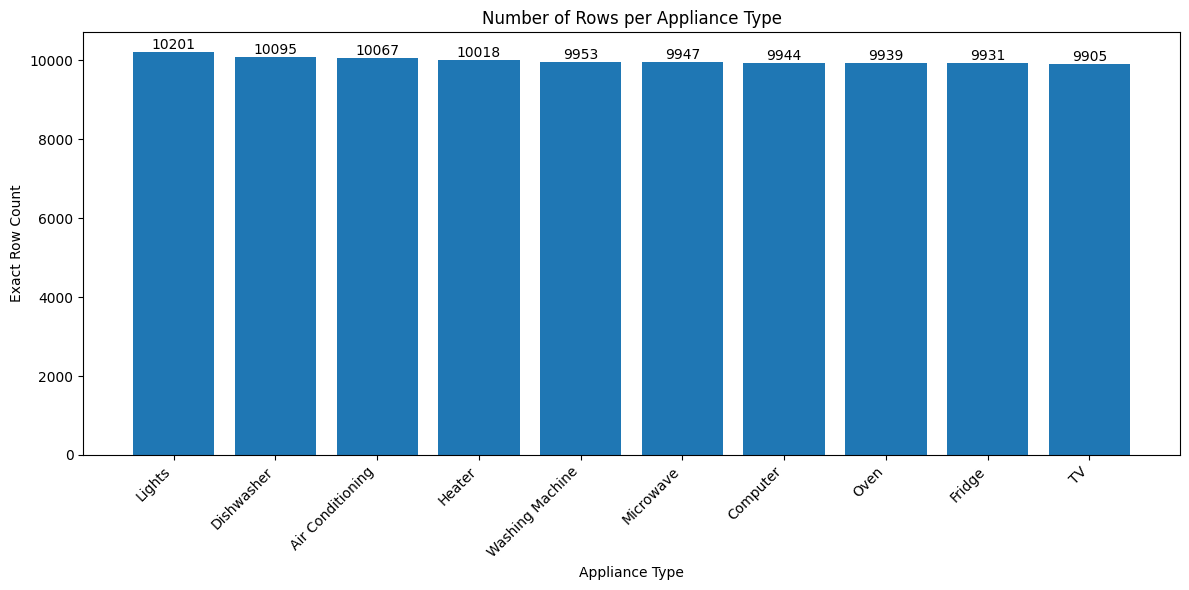

In [15]:
import matplotlib.pyplot as plt

# Count rows per appliance type
appliance_counts = df['Appliance Type'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(appliance_counts.index, appliance_counts.values)

plt.title('Number of Rows per Appliance Type')
plt.xlabel('Appliance Type')
plt.ylabel('Exact Row Count')
plt.xticks(rotation=45, ha='right')

# Add exact values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',   # EXACT number, no rounding
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


## Visualize Distribution of Energy Consumption

### Subtask:
Visualize the distribution of energy consumption using a histogram.

## Visualize Distribution of Energy Consumption

### Subtask:
Visualize the distribution of energy consumption using a histogram.

**Reasoning**:
To visualize the distribution of energy consumption, I will create a histogram using the 'Energy Consumption (kWh)' column from the DataFrame `df`. I will also add a title and axis labels to make the plot informative.



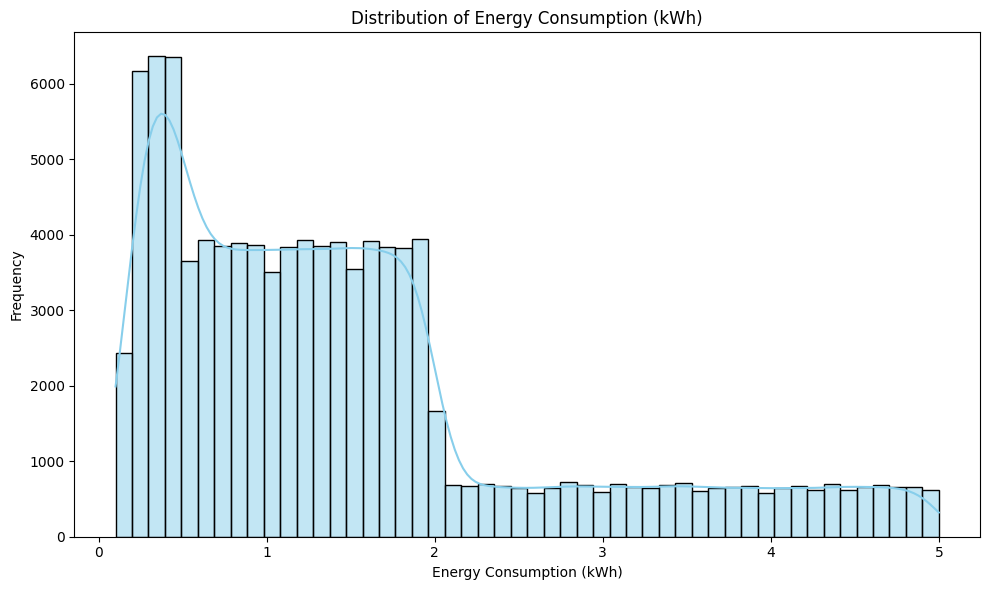

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Energy Consumption (kWh)'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Energy Consumption (kWh)')
plt.xlabel('Energy Consumption (kWh)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Visualize Distribution of Energy Consumption per appliance

### Subtask:
Visualize the distribution of energy consumption per appliance using a bar graph.

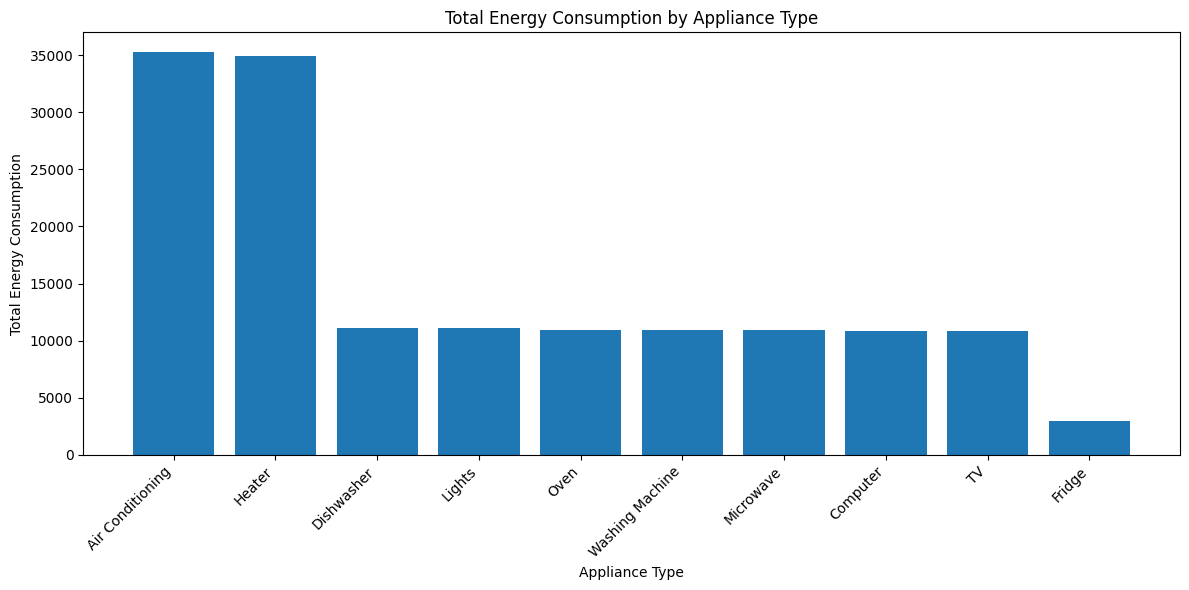

In [13]:
import matplotlib.pyplot as plt

# Group by appliance type and sum energy consumption
energy_by_appliance = (
    df.groupby('Appliance Type')['Energy Consumption (kWh)']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(energy_by_appliance.index, energy_by_appliance.values)
plt.title('Total Energy Consumption by Appliance Type')
plt.xlabel('Appliance Type')
plt.ylabel('Total Energy Consumption')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Convert and Combine Date and Time Columns

### Subtask:
Convert and combine the 'Date' and 'Time' columns into a single datetime column named 'Timestamp'.

**Reasoning**:
To convert and combine the 'Date' and 'Time' columns into a single 'Timestamp' column, I will first concatenate them into a new column, then use `pd.to_datetime` to parse this combined string into a datetime object, and finally drop the original 'Date' and 'Time' columns.



In [8]:
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.drop(columns=['Date', 'Time'], inplace=True)
print("Combined 'Date' and 'Time' into a new 'Timestamp' column and dropped original columns. Displaying the first 5 rows with the new column:")
df.head()

Combined 'Date' and 'Time' into a new 'Timestamp' column and dropped original columns. Displaying the first 5 rows with the new column:


,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size,Timestamp
0,94,Fridge,0.20,-1.0,Fall,2,2023-12-02 21:12:00
1,435,Oven,0.23,31.1,Summer,5,2023-08-06 20:11:00
2,466,Dishwasher,0.32,21.3,Fall,3,2023-11-21 06:39:00
3,496,Heater,3.92,-4.2,Winter,1,2023-01-21 21:56:00
4,137,Microwave,0.44,34.5,Summer,5,2023-08-26 04:31:00


## Convert and Save Timestamps

### Subtask:
Save the modified dataset to a new CSV file named `timestamped_smart_home_energy_consumption_dataset.csv`.


**Reasoning**:
To save the modified DataFrame `df` to a new CSV file named `timestamped_smart_home_energy_consumption_dataset.csv` without including the DataFrame index, I will use the `to_csv` method with the `index=False` argument.



In [9]:
output_filename = 'timestamped_smart_home_energy_consumption_dataset.csv'
df.to_csv(output_filename, index=False)
print(f"Modified dataset saved to '{output_filename}' successfully.")

Modified dataset saved to 'timestamped_smart_home_energy_consumption_dataset.csv' successfully.


## Final Task
Summarize the analysis performed.


## Summary:

### Data Analysis Key Findings

*   The dataset `smart_home_energy_consumption_large.csv` was successfully loaded and contains 100,000 rows and 8 columns, including 'Home ID', 'Appliance Type', 'Energy Consumption (kWh)', 'Time', 'Date', 'Outdoor Temperature (°C)', 'Season', and 'Household Size'.
*   No missing values were found across any columns in the dataset, indicating a high quality of data for these specific attributes.
*   The distribution of appliance types was visualized, showing the frequency of each type.
*   The distribution of 'Energy Consumption (kWh)' was visualized using a histogram, providing insights into the patterns and ranges of energy usage.
*   The 'Date' and 'Time' columns were successfully combined into a single 'Timestamp' column and converted to a datetime object, replacing the original columns for easier time-series analysis.
*   The modified dataset, including the new 'Timestamp' column, was successfully saved to a new CSV file named `timestamped_smart_home_energy_consumption_dataset.csv`.


